正在读取全市场数据，请稍候...
正在过滤沪深主板数据...
数据时间范围: 2010-01-04 ~ 2026-03-20
共 829 个调仓周
开始按周执行小市值+低价股调仓模拟...

✅ 交易明细已成功导出至: F:\self_quant\quant\回测excel\小市值低价轮动策略明细_每周_含持仓10只_清退市_v2.xlsx
💰 初始本金: 50,000.00 元
💰 最终总资产: 3,045.57 元
📈 策略总收益率: -93.91%


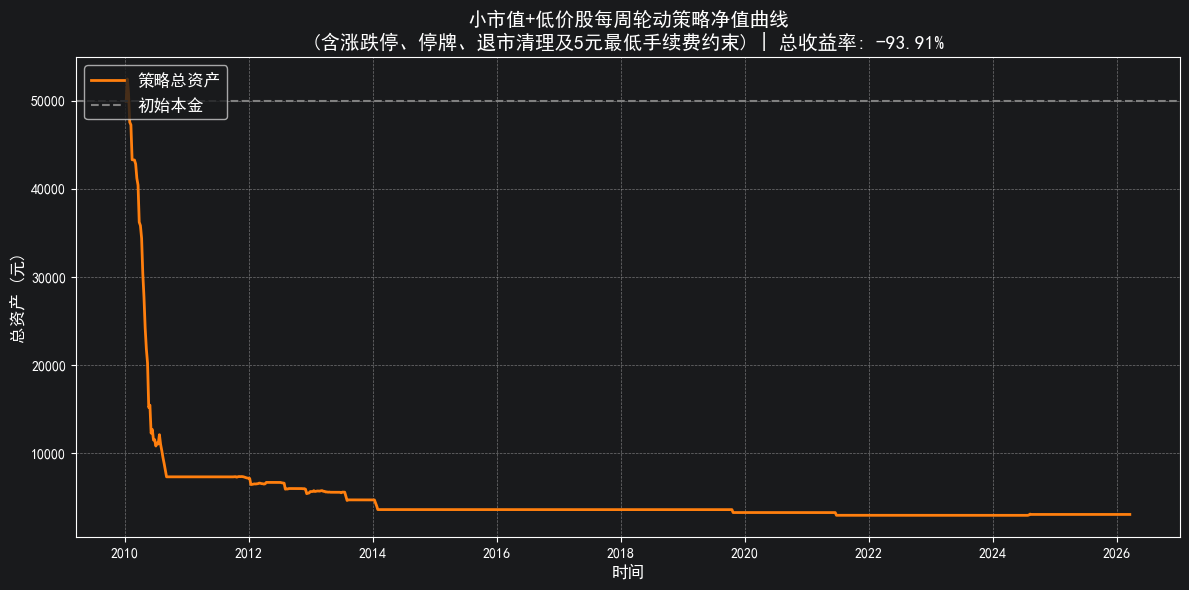

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

# 设置绘图支持中文
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

# ==========================================
# 第一步：配置参数与读取数据
# ==========================================
FILE_PATH = r"F:\self_quant\data\data\all_stocks_merged_fixed.parquet"
OUTPUT_EXCEL = r"F:\self_quant\quant\回测excel\小市值低价轮动策略明细_每周_含持仓10只_清退市_v2.xlsx"

INITIAL_CASH = 50000.0  # 初始本金 5万元
TARGET_STOCK_NUM = 10   # 目标持仓 10 只

print("正在读取全市场数据，请稍候...")
df = pd.read_parquet(FILE_PATH)
df['date'] = pd.to_datetime(df['date'])

# 过滤沪深主板股票
print("正在过滤沪深主板数据...")
main_board_mask = df['code'].str.contains(r'^sh\.60|^sz\.00', regex=True)
df = df[main_board_mask].copy()

df.sort_values(by=['date', 'code'], inplace=True)

# 提取每周最后一个交易日作为调仓日（使用 W-FRI 确保周五为周的最后一天）
trade_dates = df.groupby(pd.Grouper(key='date', freq='W-FRI'))['date'].max().dropna().tolist()

print(f"数据时间范围: {df['date'].min().date()} ~ {df['date'].max().date()}")
print(f"共 {len(trade_dates)} 个调仓周")

# ==========================================
# 第二步：定义交易费率计算函数
# ==========================================
def calculate_fees(trade_type, price, volume):
    """
    计算交易费用。
    佣金：万分之二点五，最低 5 元
    过户费：万分之一
    印花税：卖出时万分之五
    """
    amount = price * volume
    commission = max(5.0, amount * 0.00025)
    transfer_fee = amount * 0.00001
    stamp_duty = amount * 0.0005 if trade_type == 'sell' else 0.0
    total_fee = commission + transfer_fee + stamp_duty
    return total_fee, amount


def compute_total_asset(cash, positions, current_prices_dict):
    """
    计算总资产（纯函数，无副作用）。
    - 正常交易股票：按当前市价估值
    - 停牌股：按停牌前收盘价估值（但标记为冻结状态）
    - 退市/数据缺失股：按 0 估值
    """
    stock_value = 0.0
    for code, pos in positions.items():
        price = current_prices_dict.get(code)
        if price is not None and price > 0:
            stock_value += pos['volume'] * price
        # 如果 price 为 None 或 0，说明该股当天无数据（退市或数据缺失），按 0 估值
    return cash + stock_value

# ==========================================
# 第三步：账户类与回测主引擎
# ==========================================
class Account:
    def __init__(self, initial_cash):
        self.cash = initial_cash
        self.positions = {}           # {code: {'volume': int, 'buy_price': float}}
        self.trade_logs = []
        self.history_assets = []      # 记录调仓完成后的总资产

account = Account(INITIAL_CASH)

print("开始按周执行小市值+低价股调仓模拟...")

for date in trade_dates:
    daily_data = df[df['date'] == date].set_index('code')
    current_prices = daily_data['close'].to_dict()
    status_dict = daily_data['tradestatus'].to_dict()
    st_dict = daily_data['isST'].to_dict()
    pct_chg_dict = daily_data['pctChg'].to_dict()
    stock_status_dict = daily_data['stock_status'].to_dict()

    # ----------------------------------------------------------------
    # 选股逻辑
    # ----------------------------------------------------------------
    valid_pool = daily_data[
        (daily_data['tradestatus'] == 1) &
        (daily_data['isST'] == 0) &
        (daily_data['peTTM'] > 0) & (daily_data['peTTM'].notna()) &
        (daily_data['pbMRQ'] > 0) & (daily_data['pbMRQ'].notna()) &
        (daily_data['流通市值'].notna())  # 确保流通市值不为空
    ].copy()

    target_codes = []
    if len(valid_pool) >= 50:
        smallest_50 = valid_pool.sort_values(by='流通市值', ascending=True).head(50).copy()
        target_codes = smallest_50.sort_values(by='close', ascending=True).head(TARGET_STOCK_NUM).index.tolist()

    # ----------------------------------------------------------------
    # 卖出逻辑
    # ----------------------------------------------------------------
    current_holdings = list(account.positions.keys())

    for code in current_holdings:
        # ----- 检测退市：利用 stock_status 字段或数据完全缺失 -----
        is_delisted = (
            code not in daily_data.index or
            (code in daily_data.index and stock_status_dict.get(code, '') == '退市票')
        )

        if is_delisted:
            lost_vol = account.positions[code]['volume']
            buy_price = account.positions[code]['buy_price']
            loss_amount = lost_vol * buy_price

            # 从持仓中移除，现金不增加（价值归零）
            del account.positions[code]

            account.trade_logs.append({
                '日期': date, '股票代码': code, '买卖方向': '强制清理(退市)',
                '成交价': 0, '成交股数': lost_vol,
                '成交金额': 0, '交易费': 0,
                '可用现金': round(account.cash, 2),
                '总资产': round(compute_total_asset(account.cash, account.positions, current_prices), 2),
                '备注': f'退市，全额计提亏损 {round(loss_amount, 2)}元（买入成本）',
                '当前实仓股票': ", ".join(list(account.positions.keys()))
            })
            continue
        # ---------------------------------------------------------

        if code not in target_codes:
            is_trading = status_dict.get(code, 0) == 1
            pct_chg = pct_chg_dict.get(code, 0)
            # 处理 pctChg 为 NaN 的情况
            if pd.isna(pct_chg):
                pct_chg = 0.0

            if is_trading and pct_chg > -9.3:
                sell_price = current_prices[code]
                sell_vol = account.positions[code]['volume']
                fee, amount = calculate_fees('sell', sell_price, sell_vol)

                account.cash += (amount - fee)
                del account.positions[code]

                account.trade_logs.append({
                    '日期': date, '股票代码': code, '买卖方向': '卖出',
                    '成交价': sell_price, '成交股数': sell_vol,
                    '成交金额': round(amount, 2), '交易费': round(fee, 2),
                    '可用现金': round(account.cash, 2),
                    '总资产': round(compute_total_asset(account.cash, account.positions, current_prices), 2),
                    '备注': '正常卖出',
                    '当前实仓股票': ", ".join(list(account.positions.keys()))
                })
            elif not is_trading:
                account.trade_logs.append({
                    '日期': date, '股票代码': code, '买卖方向': '卖出失败(停牌)',
                    '成交价': 0, '成交股数': 0, '成交金额': 0, '交易费': 0,
                    '可用现金': round(account.cash, 2),
                    '总资产': round(compute_total_asset(account.cash, account.positions, current_prices), 2),
                    '备注': '停牌或无交易数据，强制保留',
                    '当前实仓股票': ", ".join(list(account.positions.keys()))
                })
            elif pct_chg <= -9.3:
                account.trade_logs.append({
                    '日期': date, '股票代码': code, '买卖方向': '卖出失败(跌停)',
                    '成交价': 0, '成交股数': 0, '成交金额': 0, '交易费': 0,
                    '可用现金': round(account.cash, 2),
                    '总资产': round(compute_total_asset(account.cash, account.positions, current_prices), 2),
                    '备注': f'跌幅 {pct_chg:.2f}% 封死跌停',
                    '当前实仓股票': ", ".join(list(account.positions.keys()))
                })

    # ----------------------------------------------------------------
    # 买入逻辑
    # ----------------------------------------------------------------
    stocks_to_buy = [code for code in target_codes if code not in account.positions]

    # 计算剩余空余坑位
    current_pos_count = len(account.positions)
    free_slots = max(0, TARGET_STOCK_NUM - current_pos_count)
    actual_stocks_to_buy = stocks_to_buy[:free_slots]

    if len(actual_stocks_to_buy) > 0:
        target_cash_per_stock = account.cash / len(actual_stocks_to_buy)

        for code in actual_stocks_to_buy:
            is_trading = status_dict.get(code, 0) == 1
            pct_chg = pct_chg_dict.get(code, 0)
            if pd.isna(pct_chg):
                pct_chg = 0.0
            is_st = st_dict.get(code, 0) == 1

            if is_trading and not is_st and pct_chg < 9.3:
                buy_price = current_prices[code]
                # 先估算实际可用的资金（扣除手续费）
                # 模拟买入100股来估算手续费，再反推最大可买股数
                estimated_fee, _ = calculate_fees('buy', buy_price, 100)
                # 每只股票可用资金 = 均分资金 - 预估手续费
                usable_cash = target_cash_per_stock - estimated_fee
                if usable_cash <= 0:
                    continue
                affordable_shares = int(usable_cash / buy_price)
                buy_vol = (affordable_shares // 100) * 100

                if buy_vol >= 100:
                    fee, amount = calculate_fees('buy', buy_price, buy_vol)
                    if account.cash >= (amount + fee):
                        account.cash -= (amount + fee)
                        account.positions[code] = {'volume': buy_vol, 'buy_price': buy_price}

                        account.trade_logs.append({
                            '日期': date, '股票代码': code, '买卖方向': '买入',
                            '成交价': buy_price, '成交股数': buy_vol,
                            '成交金额': round(amount, 2), '交易费': round(fee, 2),
                            '可用现金': round(account.cash, 2),
                            '总资产': round(compute_total_asset(account.cash, account.positions, current_prices), 2),
                            '备注': '正常买入',
                            '当前实仓股票': ", ".join(list(account.positions.keys()))
                        })
            elif pct_chg >= 9.3:
                account.trade_logs.append({
                    '日期': date, '股票代码': code, '买卖方向': '买入失败(涨停)',
                    '成交价': 0, '成交股数': 0, '成交金额': 0, '交易费': 0,
                    '可用现金': round(account.cash, 2),
                    '总资产': round(compute_total_asset(account.cash, account.positions, current_prices), 2),
                    '备注': f'涨幅 {pct_chg:.2f}% 封死涨停',
                    '当前实仓股票': ", ".join(list(account.positions.keys()))
                })

    # ----------------------------------------------------------------
    # 调仓完成后记录总资产（反映调仓后的真实资产状况）
    # ----------------------------------------------------------------
    post_rebalance_asset = compute_total_asset(account.cash, account.positions, current_prices)
    account.history_assets.append({'date': date, 'total_asset': post_rebalance_asset})

# ==========================================
# 第四步：输出结果与可视化
# ==========================================
df_trades = pd.DataFrame(account.trade_logs)
df_trades.to_excel(OUTPUT_EXCEL, index=False)
print(f"\n✅ 交易明细已成功导出至: {OUTPUT_EXCEL}")

df_assets = pd.DataFrame(account.history_assets)
df_assets.set_index('date', inplace=True)
final_asset = df_assets['total_asset'].iloc[-1]
total_return = (final_asset - INITIAL_CASH) / INITIAL_CASH * 100

print(f"💰 初始本金: {INITIAL_CASH:,.2f} 元")
print(f"💰 最终总资产: {final_asset:,.2f} 元")
print(f"📈 策略总收益率: {total_return:.2f}%")

# 绘制收益曲线
plt.figure(figsize=(12, 6))
plt.plot(df_assets.index, df_assets['total_asset'], color='#ff7f0e', linewidth=2, label='策略总资产')
plt.title(
    f'小市值+低价股每周轮动策略净值曲线\n'
    f'(含涨跌停、停牌、退市清理及5元最低手续费约束) | 总收益率: {total_return:.2f}%',
    fontsize=14
)
plt.xlabel('时间', fontsize=12)
plt.ylabel('总资产 (元)', fontsize=12)
plt.axhline(y=INITIAL_CASH, color='gray', linestyle='--', label='初始本金')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(loc='upper left', fontsize=12)
plt.tight_layout()
plt.show()